# Introduction

<center><img src="https://i.imgur.com/9hLRsjZ.jpg" height=400></center>

This dataset was scraped from [nextspaceflight.com](https://nextspaceflight.com/launches/past/?page=1) and includes all the space missions since the beginning of Space Race between the USA and the Soviet Union in 1957!

### Install Package with Country Codes

In [93]:
%pip install iso3166

Note: you may need to restart the kernel to use updated packages.


### Upgrade Plotly

Run the cell below if you are working with Google Colab.

In [95]:
%pip install --upgrade plotly

Note: you may need to restart the kernel to use updated packages.


### Import Statements

In [97]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# These might be helpful:
from iso3166 import countries
from datetime import datetime, timedelta

### Notebook Presentation

In [99]:
pd.options.display.float_format = '{:,.2f}'.format

### Load the Data

In [101]:
df_data = pd.read_csv('mission_launches.csv')

# Preliminary Data Exploration

* What is the shape of `df_data`? 
* How many rows and columns does it have?
* What are the column names?
* Are there any NaN values or duplicates?

In [103]:
df_data.shape

(4324, 9)

In [105]:
df_data.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Organisation', 'Location', 'Date',
       'Detail', 'Rocket_Status', 'Price', 'Mission_Status'],
      dtype='object')

In [106]:
df_data.isna().sum()

Unnamed: 0.1         0
Unnamed: 0           0
Organisation         0
Location             0
Date                 0
Detail               0
Rocket_Status        0
Price             3360
Mission_Status       0
dtype: int64

## Data Cleaning - Check for Missing Values and Duplicates

Consider removing columns containing junk data. 

In [108]:
df_data.duplicated().sum()

0

## Descriptive Statistics

In [111]:
df_data.describe()

,Unnamed: 0.1,Unnamed: 0
count,"4,324.00","4,324.00"
mean,"2,161.50","2,161.50"
std,"1,248.38","1,248.38"
min,0.00,0.00
25%,"1,080.75","1,080.75"
50%,"2,161.50","2,161.50"
75%,"3,242.25","3,242.25"
max,"4,323.00","4,323.00"


# Number of Launches per Company

Create a chart that shows the number of space mission launches by organisation.

In [114]:
launches_per_company = (
    df_data["Organisation"]
    .value_counts()
    .reset_index()
)

launches_per_company.columns = ["Organisation", "Launches"]

In [115]:
top_20 = launches_per_company.head(20)
fig = px.bar(
    top_20,
    x="Launches",
    y="Organisation",
    orientation="h",
    color="Launches",
    color_continuous_scale="Viridis",
    title="Top 20 Organisations by Number of Space Launches"
)

fig.update_layout(
    yaxis={"categoryorder": "total ascending"},
    xaxis_title="Number of Launches",
    yaxis_title="Organisation",
    title_x=0.5,
    height=700
)

fig.show()

# Number of Active versus Retired Rockets

How many rockets are active compared to those that are decomissioned? 

In [122]:
rocket_status = (
    df_data["Rocket_Status"]
    .value_counts()
    .reset_index()
)

rocket_status.columns = ["Rocket Status", "Count"]

rocket_status

,Rocket Status,Count
0,StatusRetired,3534
1,StatusActive,790


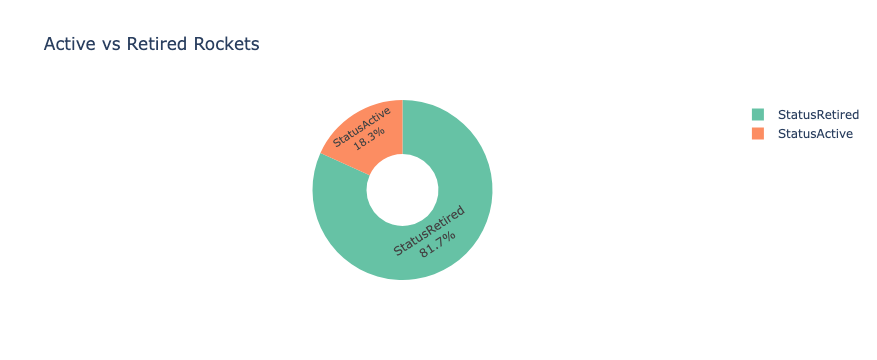

In [126]:
fig = px.pie(
    rocket_status,
    names="Rocket Status",
    values="Count",
    title="Active vs Retired Rockets",
    hole=0.4,
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_traces(textposition="inside", textinfo="percent+label")

fig.show()

# Distribution of Mission Status

How many missions were successful?
How many missions failed?

In [133]:
mission_status = (
    df_data["Mission_Status"]
    .value_counts()
    .reset_index()
)

mission_status.columns = ["Mission Status", "Count"]

mission_status

,Mission Status,Count
0,Success,3879
1,Failure,339
2,Partial Failure,102
3,Prelaunch Failure,4


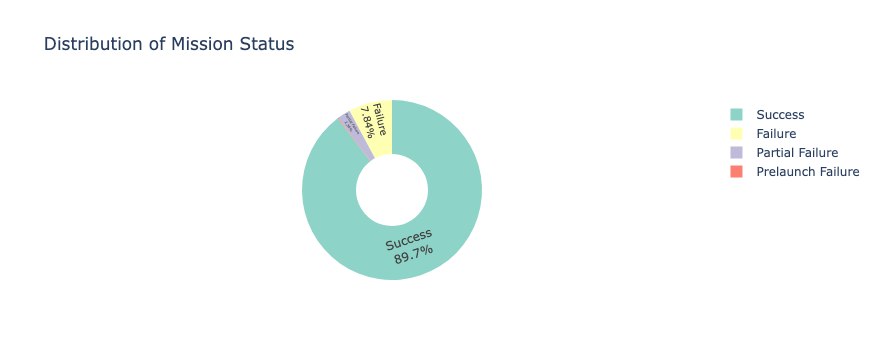

In [135]:
import plotly.express as px

fig = px.pie(
    mission_status,
    names="Mission Status",
    values="Count",
    title="Distribution of Mission Status",
    hole=0.4,
    color_discrete_sequence=px.colors.qualitative.Set3
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.show()

# How Expensive are the Launches? 

Create a histogram and visualise the distribution. The price column is given in USD millions (careful of missing values). 

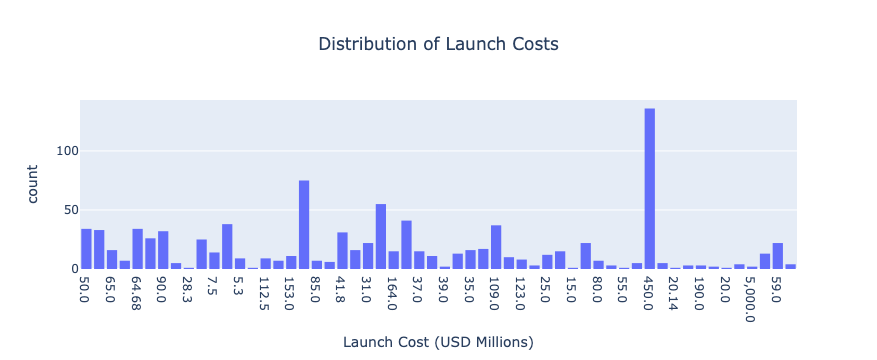

In [138]:
price_df = df_data.dropna(subset=["Price"])

fig = px.histogram(
    price_df,
    x="Price",
    nbins=50,
    title="Distribution of Launch Costs",
    labels={
        "Price": "Launch Cost (USD Millions)",
        "count": "Number of Launches"
    }
)

fig.update_layout(title_x=0.5)

fig.show()

# Use a Choropleth Map to Show the Number of Launches by Country

* Create a choropleth map using [the plotly documentation](https://plotly.com/python/choropleth-maps/)
* Experiment with [plotly's available colours](https://plotly.com/python/builtin-colorscales/). I quite like the sequential colour `matter` on this map. 
* You'll need to extract a `country` feature as well as change the country names that no longer exist.

Wrangle the Country Names

You'll need to use a 3 letter country code for each country. You might have to change some country names.

* Russia is the Russian Federation
* New Mexico should be USA
* Yellow Sea refers to China
* Shahrud Missile Test Site should be Iran
* Pacific Missile Range Facility should be USA
* Barents Sea should be Russian Federation
* Gran Canaria should be USA


You can use the iso3166 package to convert the country names to Alpha3 format.

In [141]:
df_data["Country"] = df_data["Location"].str.split(",").str[-1].str.strip()

df_data[["Location", "Country"]].head()

,Location,Country
0,"LC-39A, Kennedy Space Center, Florida, USA",USA
1,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...",China
2,"Pad A, Boca Chica, Texas, USA",USA
3,"Site 200/39, Baikonur Cosmodrome, Kazakhstan",Kazakhstan
4,"SLC-41, Cape Canaveral AFS, Florida, USA",USA


In [143]:
df_data["Country"] = df_data["Country"].replace({
    "Russia": "Russian Federation",
    "USA": "United States",
    "New Mexico": "United States",
    "Yellow Sea": "China",
    "Shahrud Missile Test Site": "Iran",
    "Pacific Missile Range Facility": "United States",
    "Barents Sea": "Russian Federation",
    "Gran Canaria": "United States"
})

In [145]:
def get_iso3(country):
    try:
        return countries.get(country).alpha3
    except:
        return None

df_data["ISO_Code"] = df_data["Country"].apply(get_iso3)

In [147]:
launches_by_country = (
    df_data.groupby(["Country", "ISO_Code"])
      .size()
      .reset_index(name="Launches")
)

launches_by_country.head()

,Country,ISO_Code,Launches
0,Australia,AUS,6
1,Brazil,BRA,3
2,China,CHN,269
3,France,FRA,303
4,India,IND,76


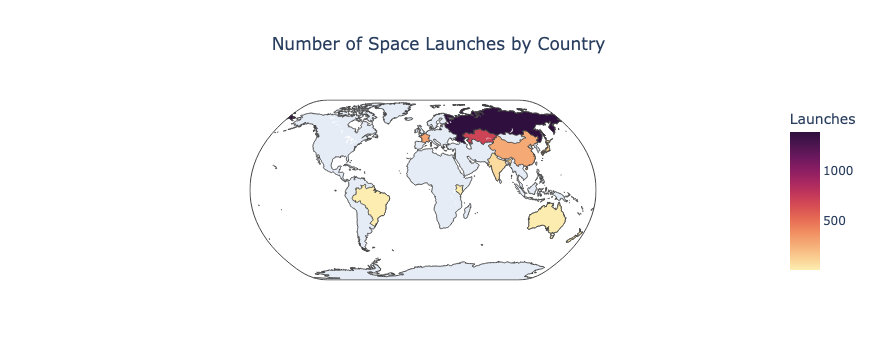

In [149]:
fig = px.choropleth(
    launches_by_country,
    locations="ISO_Code",
    color="Launches",
    hover_name="Country",
    color_continuous_scale="matter",
    projection="natural earth",
    title="Number of Space Launches by Country"
)

fig.update_layout(title_x=0.5)

fig.show()

# Use a Choropleth Map to Show the Number of Failures by Country


In [152]:
failed_df = df_data[df_data["Mission_Status"] == "Failure"].copy()

In [154]:
failed_df["Country"] = failed_df["Location"].str.split(",").str[-1].str.strip()

In [156]:
failed_df["Country"] = failed_df["Country"].replace({
    "Russia": "Russian Federation",
    "USA": "United States",
    "New Mexico": "United States",
    "Yellow Sea": "China",
    "Shahrud Missile Test Site": "Iran",
    "Pacific Missile Range Facility": "United States",
    "Barents Sea": "Russian Federation",
    "Gran Canaria": "United States"
})

In [158]:
from iso3166 import countries

def get_iso3(country):
    try:
        return countries.get(country).alpha3
    except:
        return None

failed_df["ISO_Code"] = failed_df["Country"].apply(get_iso3)

In [160]:
failures_by_country = (
    failed_df.groupby(["Country", "ISO_Code"])
             .size()
             .reset_index(name="Failures")
)

failures_by_country.head()

,Country,ISO_Code,Failures
0,Australia,AUS,3
1,Brazil,BRA,2
2,China,CHN,19
3,France,FRA,13
4,India,IND,8


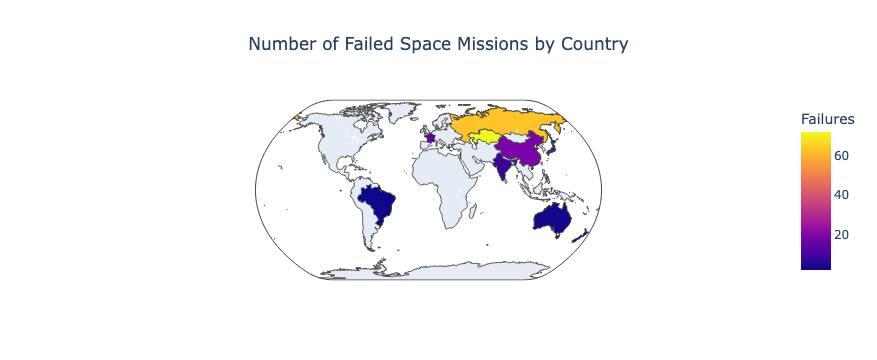

In [162]:
import plotly.express as px

fig = px.choropleth(
    failures_by_country,
    locations="ISO_Code",
    color="Failures",
    hover_name="Country",
    projection="natural earth",
    title="Number of Failed Space Missions by Country"
)

fig.update_layout(title_x=0.5)

fig.show()

# Create a Plotly Sunburst Chart of the countries, organisations, and mission status. 

In [165]:
df_data[["Country", "Organisation", "Mission_Status"]].head()

,Country,Organisation,Mission_Status
0,United States,SpaceX,Success
1,China,CASC,Success
2,United States,SpaceX,Success
3,Kazakhstan,Roscosmos,Success
4,United States,ULA,Success


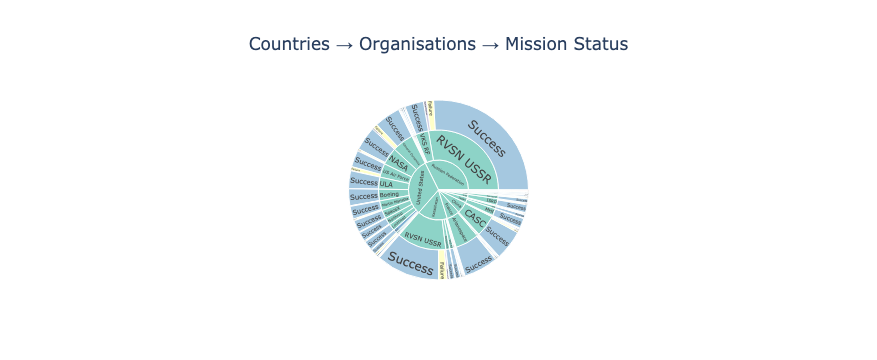

In [167]:
import plotly.express as px

fig = px.sunburst(
    df_data,
    path=["Country", "Organisation", "Mission_Status"],
    title="Countries → Organisations → Mission Status",
    color="Mission_Status",
    color_discrete_sequence=px.colors.qualitative.Set3
)

fig.update_layout(title_x=0.5)

fig.show()

# Analyse the Total Amount of Money Spent by Organisation on Space Missions

In [171]:
price_df = df_data.dropna(subset=["Price"])

In [173]:
org_spending = (
    price_df.groupby("Organisation")["Price"]
            .sum()
            .reset_index()
            .sort_values(by="Price", ascending=False)
)

org_spending.head()

,Organisation,Price
9,JAXA,90.039.039.0
17,Rocket Lab,7.57.57.57.57.57.57.57.57.57.57.57.57.5
7,ILS,65.065.065.065.065.0115.0153.0109.0130.0135.01...
18,Roscosmos,65.048.548.548.565.048.548.565.048.565.065.048...
22,US Air Force,59.059.059.059.059.059.059.059.059.059.059.059...


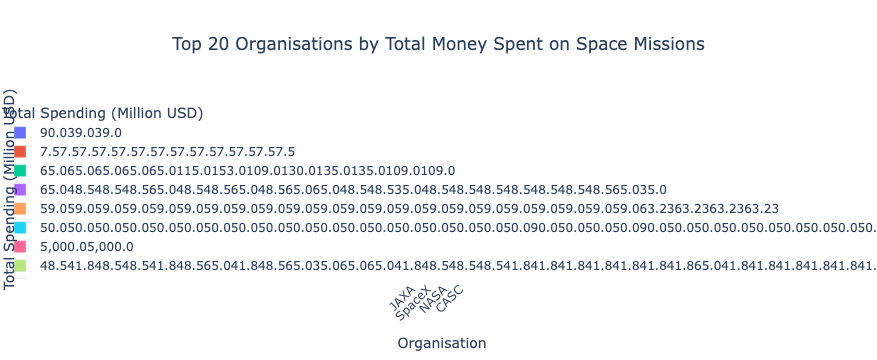

<Figure size 1000x1500 with 0 Axes>

In [175]:
plt.figure(figsize=(10,15))

fig = px.bar(
    org_spending.head(20),
    x="Organisation",
    y="Price",
    color="Price",
    color_continuous_scale="Viridis",
    title="Top 20 Organisations by Total Money Spent on Space Missions",
    labels={
        "Organisation": "Organisation",
        "Price": "Total Spending (Million USD)"
    }
)

fig.update_layout(
    title_x=0.5,
    xaxis_tickangle=-45
)

fig.show()

# Analyse the Amount of Money Spent by Organisation per Launch

In [183]:
df_data["Price"] = (
    df_data["Price"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

df_data["Price"] = pd.to_numeric(df_data["Price"], errors="coerce")

In [185]:
price_df = df_data.dropna(subset=["Price"])

In [187]:
avg_spending = (
    price_df.groupby("Organisation")["Price"]
            .mean()
            .reset_index()
            .sort_values(by="Price", ascending=False)
)

avg_spending.head()

,Organisation,Price
16,RVSN USSR,"5,000.00"
14,NASA,511.95
1,Boeing,177.29
0,Arianespace,170.26
21,ULA,151.00


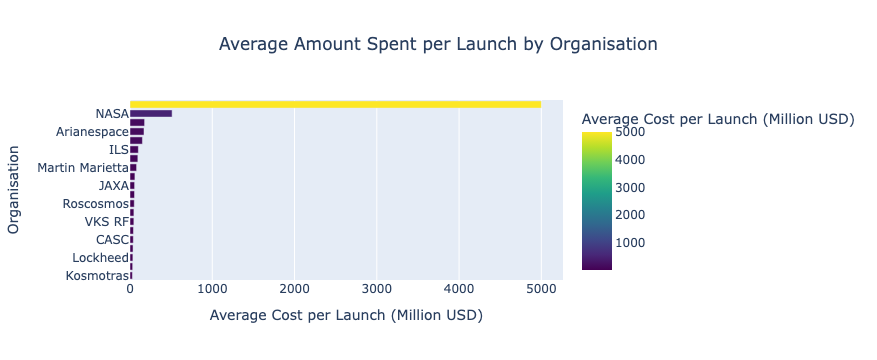

In [189]:
fig = px.bar(
    avg_spending.head(20),
    x="Price",
    y="Organisation",
    orientation="h",
    color="Price",
    color_continuous_scale="Viridis",
    title="Average Amount Spent per Launch by Organisation",
    labels={
        "Price": "Average Cost per Launch (Million USD)",
        "Organisation": "Organisation"
    }
)

fig.update_layout(
    title_x=0.5,
    yaxis={"categoryorder": "total ascending"}
)

fig.show()

# Chart the Number of Launches per Year

In [191]:
df_data["Date"] = pd.to_datetime(df_data["Date"], errors="coerce")

df_data["Year"] = df_data["Date"].dt.year

In [193]:
launches_per_year = (
    df_data.groupby("Year")
      .size()
      .reset_index(name="Launches")
)

launches_per_year.head()

,Year,Launches
0,"1,957.00",3
1,"1,958.00",22
2,"1,959.00",20
3,"1,960.00",38
4,"1,961.00",52


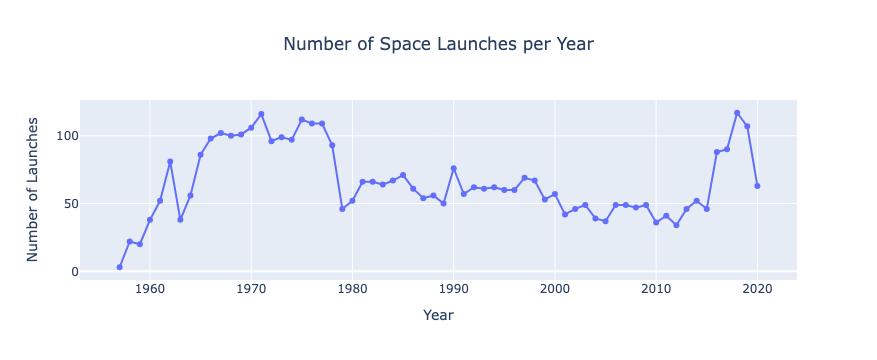

In [195]:
fig = px.line(
    launches_per_year,
    x="Year",
    y="Launches",
    markers=True,
    title="Number of Space Launches per Year",
    labels={
        "Year": "Year",
        "Launches": "Number of Launches"
    }
)

fig.update_layout(title_x=0.5)

fig.show()

# Chart the Number of Launches Month-on-Month until the Present

Which month has seen the highest number of launches in all time? Superimpose a rolling average on the month on month time series chart. 

In [197]:
df_data["Date"] = pd.to_datetime(df_data["Date"], errors="coerce")

In [199]:
monthly_launches = (
    df_data.set_index("Date")
      .resample("ME")
      .size()
      .reset_index(name="Launches")
)

monthly_launches.head()

,Date,Launches
0,1957-10-31 00:00:00+00:00,1
1,1957-11-30 00:00:00+00:00,1
2,1957-12-31 00:00:00+00:00,1
3,1958-01-31 00:00:00+00:00,0
4,1958-02-28 00:00:00+00:00,2


In [201]:
monthly_launches["Rolling Average"] = (
    monthly_launches["Launches"]
    .rolling(window=12)
    .mean()
)

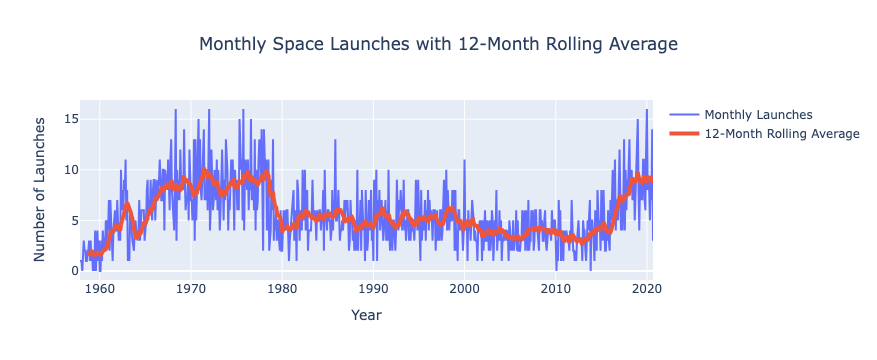

In [207]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=monthly_launches["Date"],
        y=monthly_launches["Launches"],
        mode="lines",
        name="Monthly Launches"
    )
)

fig.add_trace(
    go.Scatter(
        x=monthly_launches["Date"],
        y=monthly_launches["Rolling Average"],
        mode="lines",
        name="12-Month Rolling Average",
        line=dict(width=4)
    )
)

fig.update_layout(
    title="Monthly Space Launches with 12-Month Rolling Average",
    xaxis_title="Year",
    yaxis_title="Number of Launches",
    title_x=0.5
)

fig.show()

# Launches per Month: Which months are most popular and least popular for launches?

Some months have better weather than others. Which time of year seems to be best for space missions?

In [209]:
df_data["Month"] = df_data["Date"].dt.month_name()

In [211]:
month_launches = (
    df_data["Month"]
      .value_counts()
      .reset_index()
)

month_launches.columns = ["Month", "Launches"]

In [213]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

month_launches["Month"] = pd.Categorical(
    month_launches["Month"],
    categories=month_order,
    ordered=True
)

month_launches = month_launches.sort_values("Month")

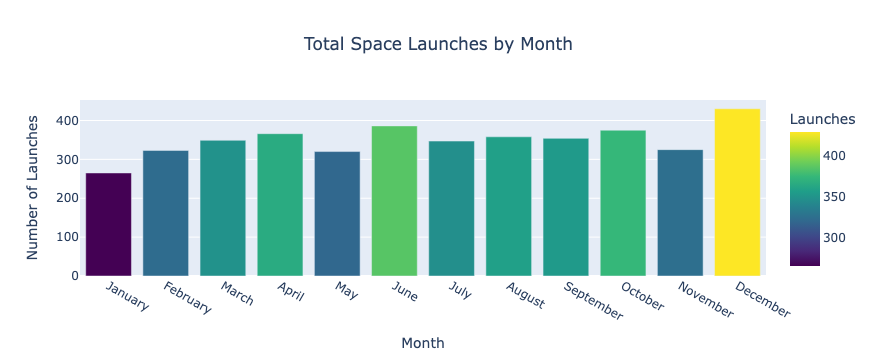

In [215]:
fig = px.bar(
    month_launches,
    x="Month",
    y="Launches",
    color="Launches",
    color_continuous_scale="Viridis",
    title="Total Space Launches by Month"
)

fig.update_layout(
    title_x=0.5,
    xaxis_title="Month",
    yaxis_title="Number of Launches"
)

fig.show()

# How has the Launch Price varied Over Time? 

Create a line chart that shows the average price of rocket launches over time. 

In [217]:
df_data["Date"] = pd.to_datetime(df_data["Date"], errors="coerce")

df_data["Price"] = pd.to_numeric(df_data["Price"], errors="coerce")

In [219]:
price_per_year = (
    df_data.dropna(subset=["Price"])
           .groupby(df_data["Date"].dt.year)["Price"]
           .mean()
           .reset_index()
)

price_per_year.columns = ["Year", "Average Price"]

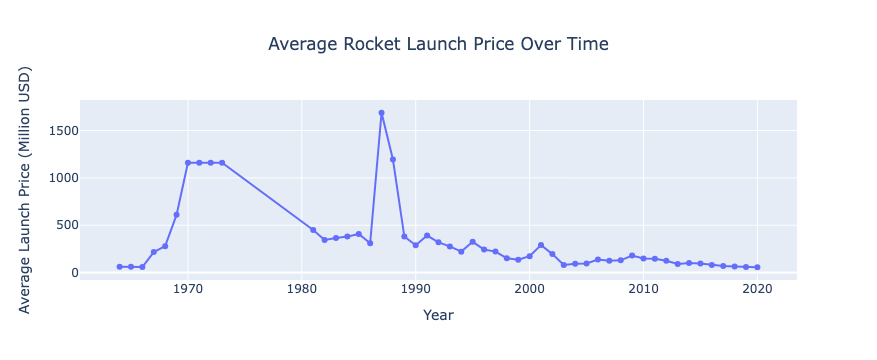

In [221]:
fig = px.line(
    price_per_year,
    x="Year",
    y="Average Price",
    markers=True,
    title="Average Rocket Launch Price Over Time",
    labels={
        "Year": "Year",
        "Average Price": "Average Launch Price (Million USD)"
    }
)

fig.update_layout(
    title_x=0.5,
    xaxis_title="Year",
    yaxis_title="Average Launch Price (Million USD)"
)

fig.show()

# Chart the Number of Launches over Time by the Top 10 Organisations. 

How has the dominance of launches changed over time between the different players? 

In [223]:
df_data["Date"] = pd.to_datetime(df_data["Date"], errors="coerce")
df_data["Year"] = df_data["Date"].dt.year

In [225]:
top10_orgs = (
    df_data["Organisation"]
    .value_counts()
    .head(10)
    .index
)

In [227]:
top10_data = df_data[
    df_data["Organisation"].isin(top10_orgs)
]

In [229]:
launches_by_year = (
    top10_data
    .groupby(["Year", "Organisation"])
    .size()
    .reset_index(name="Launches")
)

launches_by_year.head()

,Year,Organisation,Launches
0,"1,957.00",RVSN USSR,2
1,"1,958.00",NASA,2
2,"1,958.00",RVSN USSR,5
3,"1,958.00",US Air Force,2
4,"1,959.00",General Dynamics,1


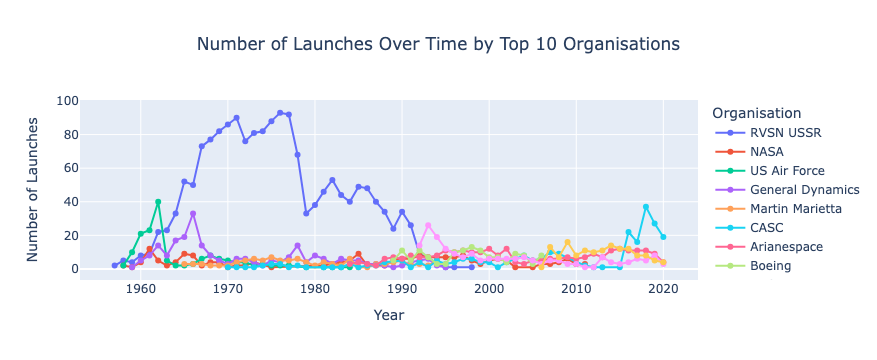

In [231]:
fig = px.line(
    launches_by_year,
    x="Year",
    y="Launches",
    color="Organisation",
    markers=True,
    title="Number of Launches Over Time by Top 10 Organisations",
    labels={
        "Year": "Year",
        "Launches": "Number of Launches",
        "Organisation": "Organisation"
    }
)

fig.update_layout(
    title_x=0.5,
    hovermode="x unified"
)

fig.show()

# Cold War Space Race: USA vs USSR

The cold war lasted from the start of the dataset up until 1991. 

In [233]:
cold_war = df_data[df_data["Date"].dt.year <= 1991].copy()

In [235]:
usa_ussr = cold_war[
    cold_war["Country"].isin(["United States", "Russian Federation"])
].copy()

In [237]:
launches = (
    usa_ussr.groupby([
        usa_ussr["Date"].dt.year,
        "Country"
    ])
    .size()
    .reset_index(name="Launches")
)

launches.columns = ["Year", "Country", "Launches"]

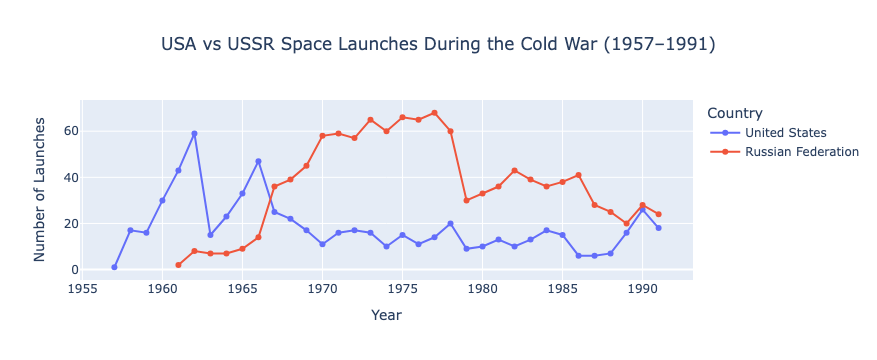

In [239]:
fig = px.line(
    launches,
    x="Year",
    y="Launches",
    color="Country",
    markers=True,
    title="USA vs USSR Space Launches During the Cold War (1957–1991)",
    labels={
        "Year": "Year",
        "Launches": "Number of Launches"
    }
)

fig.update_layout(
    title_x=0.5,
    hovermode="x unified"
)

fig.show()

## Create a Plotly Pie Chart comparing the total number of launches of the USSR and the USA

Hint: Remember to include former Soviet Republics like Kazakhstan when analysing the total number of launches. 

In [241]:
ussr_countries = ["Russian Federation", "Kazakhstan"]
usa_countries = ["United States"]

cold_war["Superpower"] = "Other"

cold_war.loc[
    cold_war["Country"].isin(ussr_countries),
    "Superpower"
] = "USSR"

cold_war.loc[
    cold_war["Country"].isin(usa_countries),
    "Superpower"
] = "USA"

In [243]:
usa_vs_ussr = cold_war[
    cold_war["Superpower"].isin(["USA", "USSR"])
]

In [245]:
launch_counts = (
    usa_vs_ussr["Superpower"]
    .value_counts()
    .reset_index()
)

launch_counts.columns = ["Country", "Launches"]

launch_counts

,Country,Launches
0,USSR,1709
1,USA,644


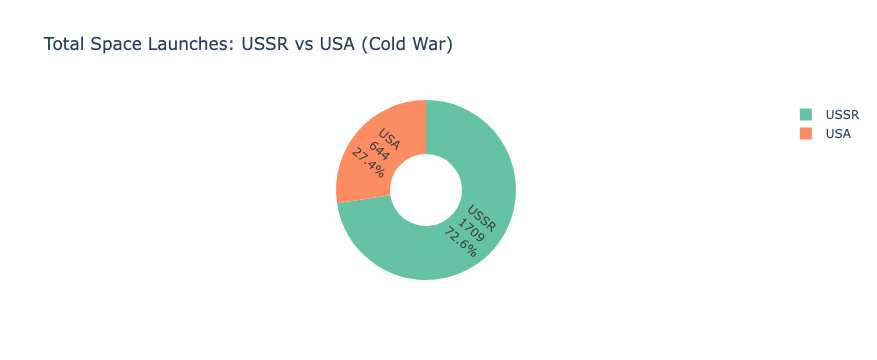

In [247]:
fig = px.pie(
    launch_counts,
    names="Country",
    values="Launches",
    title="Total Space Launches: USSR vs USA (Cold War)",
    hole=0.4,
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label+value"
)

fig.show()

## Create a Chart that Shows the Total Number of Launches Year-On-Year by the Two Superpowers

In [249]:
launches_per_year = (
    cold_war[cold_war["Superpower"].isin(["USA", "USSR"])]
    .groupby([
        cold_war["Date"].dt.year,
        "Superpower"
    ])
    .size()
    .reset_index(name="Launches")
)

launches_per_year.columns = ["Year", "Superpower", "Launches"]

launches_per_year.head()

,Year,Superpower,Launches
0,1957,USA,1
1,1957,USSR,2
2,1958,USA,17
3,1958,USSR,5
4,1959,USA,16


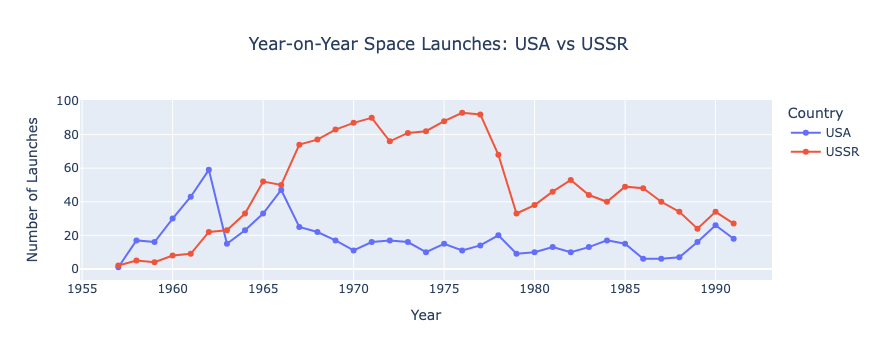

In [251]:
fig = px.line(
    launches_per_year,
    x="Year",
    y="Launches",
    color="Superpower",
    markers=True,
    title="Year-on-Year Space Launches: USA vs USSR",
    labels={
        "Year": "Year",
        "Launches": "Number of Launches",
        "Superpower": "Country"
    }
)

fig.update_layout(
    title_x=0.5,
    hovermode="x unified"
)

fig.show()

## Chart the Total Number of Mission Failures Year on Year.

In [253]:
failed_missions = df_data[
    df_data["Mission_Status"] != "Success"
].copy()

In [255]:
failures_per_year = (
    failed_missions
    .groupby(failed_missions["Date"].dt.year)
    .size()
    .reset_index(name="Failures")
)

failures_per_year.columns = ["Year", "Failures"]

failures_per_year.head()

,Year,Failures
0,"1,957.00",1
1,"1,958.00",16
2,"1,959.00",12
3,"1,960.00",19
4,"1,961.00",20


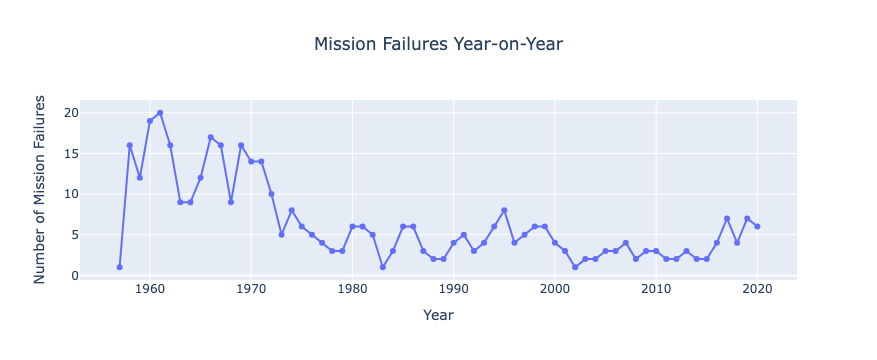

In [257]:
fig = px.line(
    failures_per_year,
    x="Year",
    y="Failures",
    markers=True,
    title="Mission Failures Year-on-Year",
    labels={
        "Year": "Year",
        "Failures": "Number of Mission Failures"
    }
)

fig.update_layout(
    title_x=0.5,
    hovermode="x unified"
)

fig.show()

## Chart the Percentage of Failures over Time

Did failures go up or down over time? Did the countries get better at minimising risk and improving their chances of success over time? 

In [259]:
yearly_stats = (
    df_data
    .groupby(df_data["Date"].dt.year)
    .agg(
        Total_Launches=("Mission_Status", "count"),
        Failed_Launches=("Mission_Status", lambda x: (x != "Success").sum())
    )
    .reset_index()
)

yearly_stats.columns = ["Year", "Total Launches", "Failed Launches"]

In [261]:
yearly_stats["Failure Percentage"] = (
    yearly_stats["Failed Launches"] /
    yearly_stats["Total Launches"]
) * 100

yearly_stats.head()

,Year,Total Launches,Failed Launches,Failure Percentage
0,"1,957.00",3,1,33.33
1,"1,958.00",22,16,72.73
2,"1,959.00",20,12,60.00
3,"1,960.00",38,19,50.00
4,"1,961.00",52,20,38.46


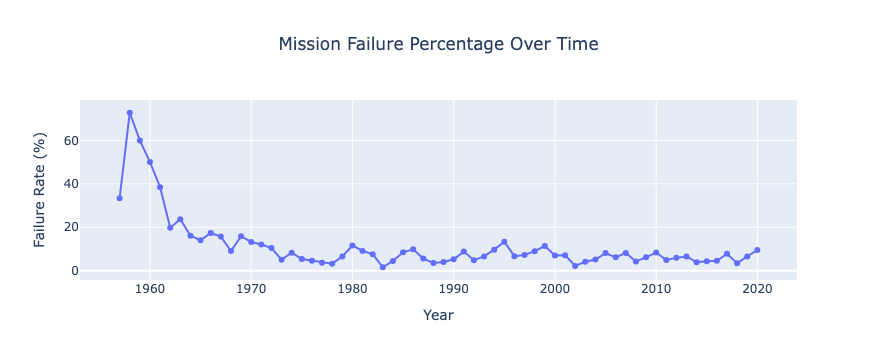

In [263]:
fig = px.line(
    yearly_stats,
    x="Year",
    y="Failure Percentage",
    markers=True,
    title="Mission Failure Percentage Over Time",
    labels={
        "Year": "Year",
        "Failure Percentage": "Failure Rate (%)"
    }
)

fig.update_layout(
    title_x=0.5,
    hovermode="x unified"
)

fig.show()

# For Every Year Show which Country was in the Lead in terms of Total Number of Launches up to and including including 2020)

Do the results change if we only look at the number of successful launches? 

In [265]:
launches_by_country = (
    df_data[df_data["Date"].dt.year <= 2020]
    .groupby([
        df_data["Date"].dt.year,
        "Country"
    ])
    .size()
    .reset_index(name="Launches")
)

launches_by_country.columns = ["Year", "Country", "Launches"]

yearly_leader = (
    launches_by_country
    .sort_values(["Year", "Launches"], ascending=[True, False])
    .groupby("Year")
    .first()
    .reset_index()
)

yearly_leader.head()

,Year,Country,Launches
0,"1,957.00",Kazakhstan,2
1,"1,958.00",United States,17
2,"1,959.00",United States,16
3,"1,960.00",United States,30
4,"1,961.00",United States,43


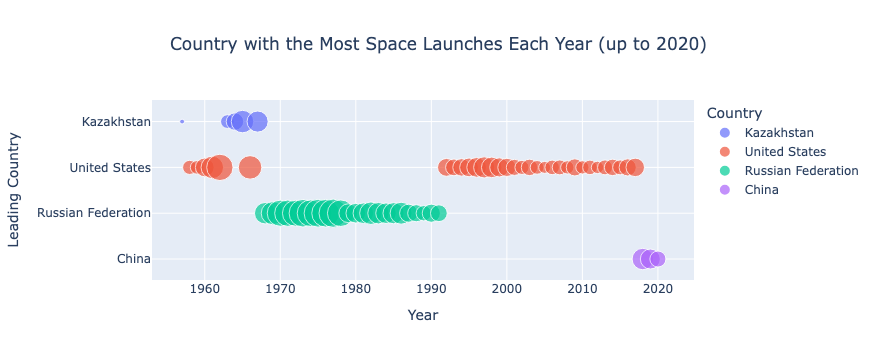

In [267]:
fig = px.scatter(
    yearly_leader,
    x="Year",
    y="Country",
    size="Launches",
    color="Country",
    hover_data=["Launches"],
    title="Country with the Most Space Launches Each Year (up to 2020)"
)

fig.update_layout(
    title_x=0.5,
    yaxis_title="Leading Country"
)

fig.show()

# Create a Year-on-Year Chart Showing the Organisation Doing the Most Number of Launches

Which organisation was dominant in the 1970s and 1980s? Which organisation was dominant in 2018, 2019 and 2020? 

In [269]:
org_launches = (
    df_data[df_data["Date"].dt.year <= 2020]
    .groupby([
        df_data["Date"].dt.year,
        "Organisation"
    ])
    .size()
    .reset_index(name="Launches")
)

org_launches.columns = ["Year", "Organisation", "Launches"]

yearly_org_leader = (
    org_launches
    .sort_values(["Year", "Launches"], ascending=[True, False])
    .groupby("Year")
    .first()
    .reset_index()
)

yearly_org_leader.head()

,Year,Organisation,Launches
0,"1,957.00",RVSN USSR,2
1,"1,958.00",AMBA,7
2,"1,959.00",US Air Force,10
3,"1,960.00",US Air Force,21
4,"1,961.00",US Air Force,23


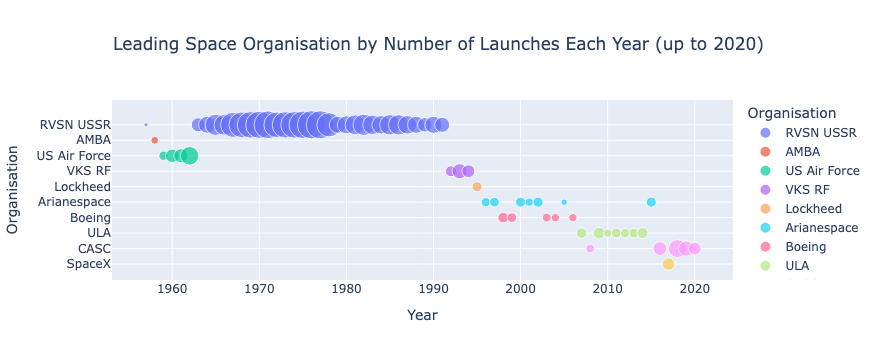

In [271]:
fig = px.scatter(
    yearly_org_leader,
    x="Year",
    y="Organisation",
    size="Launches",
    color="Organisation",
    hover_data=["Launches"],
    title="Leading Space Organisation by Number of Launches Each Year (up to 2020)"
)

fig.update_layout(
    title_x=0.5,
    yaxis_title="Organisation"
)

fig.show()